# EfficientNetV2-S — Final Training & Test Evaluation

## KHOTAA — Smart Diabetic Foot Shield

---


### Model Selection Summary

Based on the **5-fold stratified cross-validation** comparison of **6 deep learning architectures**, sorted by **Macro F1** (primary metric for imbalanced data):

| Rank | Model | CV Mean Acc | CV Std | Macro F1 | MCC | Macro AUC |
|:----:|-------|:-----------:|:------:|:--------:|:---:|:---------:|
| **1** | **EfficientNetV2-S** | **80.81%** | **1.72%** | **91.00%** | **0.8424** | **0.9848** |
| 2 | MobileNetV2 | 75.38% | 2.14% | 86.87% | 0.7653 | 0.9669 |
| 3 | DenseNet121 | 74.16% | 1.90% | 84.78% | 0.6983 | 0.9532 |
| 4 | ResNet50 | 70.71% | 1.33% | 78.42% | 0.6394 | 0.9309 |
| 5 | ResNet101 | 75.63% | 2.32% | 78.34% | 0.6270 | 0.9375 |
| 6 | GoogLeNet | 78.96% | 0.98% | 40.85% | 0.2726 | 0.7613 |

> **EfficientNetV2-S** dominates across all metrics — highest Macro F1, MCC, and AUC.

---

### Head Architecture Search (Winner)

After selecting EfficientNetV2-S, a **head architecture search** was conducted (21 random configs on fold 1, top 3 validated across all 5 folds):

| Parameter | Winner (Trial 4) |
|---|---|
| Hidden Layers | 1 |
| Hidden Sizes | [128] |
| Dropout | 0.5 |
| Activation | GELU |
| BatchNorm | No |
| **5-Fold Mean Acc** | **83.43% ± 2.90%** |
| **5-Fold Mean F1** | **84.31% ± 1.82%** |

---

### Final Training Methodology

1. **Final Training** — Retrain EfficientNetV2-S (with winning head) on **all non-test data** (train + valid combined) to maximize performance
2. **Fixed Epochs** — Train for **30 epochs** (determined by CV: average convergence at ~29 epochs), no early stopping needed
3. **Test Evaluation** — Evaluate on the **reserved test set** (never used during CV, head search, or training)

**Why train on all data?** Cross-validation already validated the model and hyperparameters. Holding back a validation set would waste data — the more training data, the better the final model.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# KAGGLE SETUP — Clone repo & install dependencies
# Run this cell FIRST on Kaggle to pull the project code and utilities.
# ══════════════════════════════════════════════════════════════════════════════
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/kaggle/working/KHOTAA'
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

# Clone the repo (skip if already cloned)
if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f"✓ Cloned {BRANCH} branch → {REPO_DIR}")
else:
    print(f"✓ Repo already exists at {REPO_DIR}")

# Change into the notebook's expected working directory
os.chdir(WORKING_DIR)
print(f"✓ Working directory: {os.getcwd()}")

# Install additional dependencies
!pip install roboflow -q
print("✓ Kaggle setup complete")

Cloning into '/kaggle/working/KHOTAA'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 583 (delta 32), reused 36 (delta 25), pack-reused 535 (from 1)
Receiving objects: 100% (583/583), 20.83 MiB | 31.74 MiB/s, done.
Resolving deltas: 100% (277/277), done.
✓ Cloned new-start branch → /kaggle/working/KHOTAA
✓ Working directory: /kaggle/working/KHOTAA/models/classification
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.0 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This 

## 1. Imports & Configuration

In [2]:
# ── Standard Library ──────────────────────────────────────────────────────────────
import sys
import os
import random
import warnings
import json
import time
warnings.filterwarnings('ignore')

# ── Numerical & Visualization ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ─────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from PIL import Image

# ── Scikit-learn ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, log_loss
from datetime import datetime

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Project imports ─────────────────────────────────────────────────────────────
sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import training_engine
importlib.reload(training_engine)
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history,
    print_classification_report, show_sample_predictions
)

# ── Roboflow Dataset ────────────────────────────────────────────────────────────
from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

# ── Configuration ───────────────────────────────────────────────────────────────
MODEL_NAME    = 'EfficientNetV2S'
BATCH_SIZE    = 32
NUM_EPOCHS    = 30       # Fixed: CV showed avg convergence at ~29.2 epochs
LEARNING_RATE = 1e-3     # Same as CV
RESULTS_DIR   = 'results/efficientnetv2s_final'
DPI           = 300

# ── Head Search Winner (Trial 4) ────────────────────────────────────────────────
WINNER_HEAD_CONFIG = {
    'n_hidden_layers': 1,
    'hidden_sizes':    [128],
    'dropout':         0.5,
    'activation':      'gelu',
    'use_batchnorm':   False,
}

# ── Device ──────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ Imports complete")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {device}")
print(f"\nConfiguration (validated by 5-fold CV + Head Search):")
print(f"  Model        : {MODEL_NAME}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Epochs       : {NUM_EPOCHS} (fixed, no early stopping)")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Optimizer    : Adam (weight_decay=1e-4)")
print(f"  Scheduler    : ReduceLROnPlateau (factor=0.3, patience=3)")
print(f"  Loss         : CrossEntropyLoss (balanced class weights)")
print(f"  Head Config  : 128 | drop=0.5 | gelu | noBN (winner from head search)")
print(f"  Dataset path : {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DFU-1 in folder:: 100%|██████████| 4462/4462 [00:00<00:00, 12094.92it/s]

✓ Imports complete
PyTorch version : 2.9.0+cu126
CUDA available  : True
Device          : cuda

Configuration (validated by 5-fold CV + Head Search):
  Model        : EfficientNetV2S
  Batch Size   : 32
  Epochs       : 30 (fixed, no early stopping)
  Learning Rate: 0.001
  Optimizer    : Adam (weight_decay=1e-4)
  Scheduler    : ReduceLROnPlateau (factor=0.3, patience=3)
  Loss         : CrossEntropyLoss (balanced class weights)
  Head Config  : 128 | drop=0.5 | gelu | noBN (winner from head search)
  Dataset path : /kaggle/working/KHOTAA/models/classification/DFU-1/


## 2. Load Dataset & Statistics

In [3]:
# ── Load dataset (auto-detects train/valid/val/test splits) ──────────────
loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# ── Initialize preprocessing (same as CV) ───────────────────────────────────
preprocessor = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# ── PyTorch Dataset class ───────────────────────────────────────────────────────
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── Load all splits ──────────────────────────────────────────────────────────
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_test, y_test   = loader.load_split_paths('test')

# ── FINAL TRAINING: combine train + valid for maximum training data ──────────
# CV already validated the model — no need to hold back a validation set
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# ── Create datasets ──────────────────────────────────────────────────────────
train_dataset = DFUDataset(X_all, y_all, transform=train_transform)
test_dataset  = DFUDataset(X_test, y_test, transform=val_test_transform)

# ── Create DataLoaders ───────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Training samples:   {len(X_all):,} (train + valid combined)")
print(f"  - from train/:    {len(X_train):,}")
print(f"  - from valid/:    {len(X_val):,}")
print(f"Test samples:       {len(X_test):,} (reserved, never seen)")
print(f"Total:              {len(X_all) + len(X_test):,}")
print(f"{'='*60}")

[DatasetLoader] Root: /kaggle/working/KHOTAA/models/classification/DFU-1
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Both', 'Infection', 'Ischaemia', 'None']

Classes: ['Both', 'Infection', 'Ischaemia', 'None']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 3112 images
[DatasetLoader] Split 'valid': 889 images
[DatasetLoader] Split 'test': 445 images

DATASET SUMMARY
Training samples:   4,001 (train + valid combined)
  - from train/:    3,112
  - from valid/:    889
Test samples:       445 (reserved, never seen)
Total:              4,446


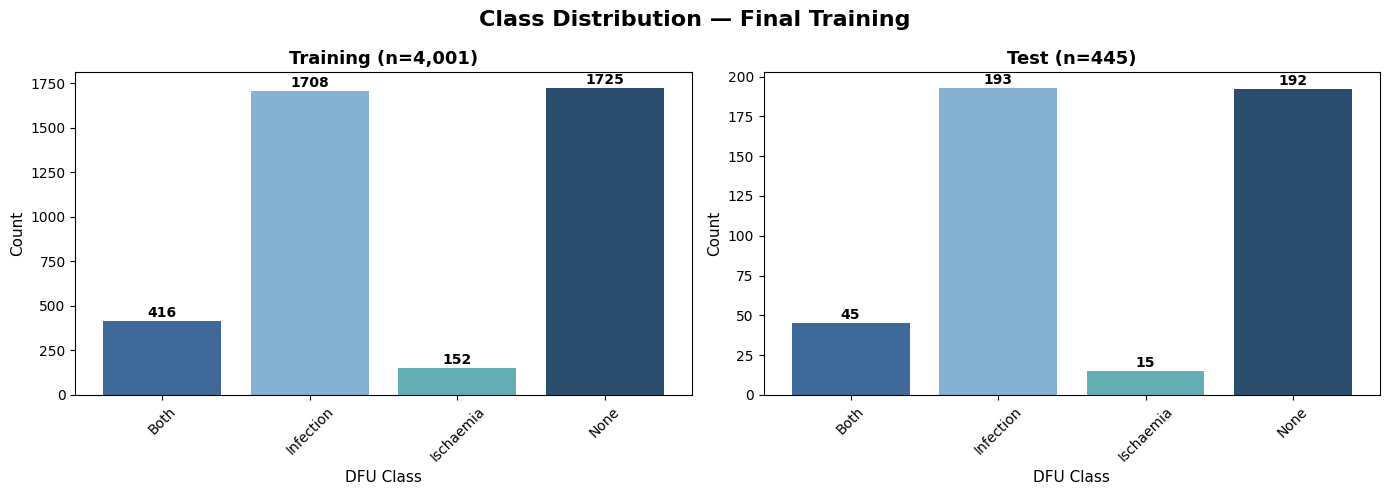

In [4]:
# ── Class distribution visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Final Training', fontsize=16, fontweight='bold')

colors = ['#3D6A99', '#85B1D2', '#64ADB3', '#2A4D6E']

# Training (combined)
ax = axes[0]
unique, counts = np.unique(y_all, return_counts=True)
bars = ax.bar([classes[u] for u in unique], counts, color=colors)
ax.set_title(f'Training (n={len(y_all):,})', fontsize=13, fontweight='bold')
ax.set_xlabel('DFU Class', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Test
ax = axes[1]
unique, counts = np.unique(y_test, return_counts=True)
bars = ax.bar([classes[u] for u in unique], counts, color=colors)
ax.set_title(f'Test (n={len(y_test)})', fontsize=13, fontweight='bold')
ax.set_xlabel('DFU Class', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Model Definition (EfficientNetV2-S + Winning Head)

The classification head was determined by our **Head Architecture Search**:  
`1280 → Linear(128) → GELU → Dropout(0.5) → Linear(4)`

This architecture achieved the **best 5-fold mean accuracy (83.43%)** and **lowest variance** among all candidates tested.

In [5]:
# ── Activation map (same as head search notebook) ───────────────────────────
ACTIVATION_MAP = {
    'relu': nn.ReLU,
    'gelu': nn.GELU,
    'silu': nn.SiLU,
}


class EfficientNetV2SFinal(nn.Module):
    """
    EfficientNetV2-S with the winning classification head from head search.

    Architecture:
        EfficientNetV2-S backbone (ImageNet pretrained, fully trainable)
        → AdaptiveAvgPool2d → Flatten
        → Linear(1280, 128) → GELU → Dropout(0.5)
        → Linear(128, 4)

    Head config (Trial 4 — winner):
        n_hidden_layers: 1
        hidden_sizes:    [128]
        dropout:         0.5
        activation:      gelu
        use_batchnorm:   False
    """
    def __init__(self, head_config, num_classes=4, pretrained=True):
        super().__init__()

        if pretrained:
            backbone = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        else:
            backbone = models.efficientnet_v2_s(weights=None)

        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        # Build classification head from config
        act_fn = ACTIVATION_MAP[head_config['activation']]
        layers = [nn.Flatten()]

        in_features = 1280  # EfficientNetV2-S backbone output
        for h_size in head_config['hidden_sizes']:
            layers.append(nn.Linear(in_features, h_size))
            if head_config['use_batchnorm']:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(act_fn())
            layers.append(nn.Dropout(head_config['dropout']))
            in_features = h_size

        layers.append(nn.Linear(in_features, num_classes))
        self.classifier = nn.Sequential(*layers)

        # Kaiming init on head (same as head search)
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

        self.head_config = head_config

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


# ── Create model with winning head config ────────────────────────────────────
model = EfficientNetV2SFinal(
    head_config=WINNER_HEAD_CONFIG,
    num_classes=num_classes,
    pretrained=True
)
model = model.to(device)

# ── Model summary ──────────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
head_params      = sum(p.numel() for p in model.classifier.parameters())

print(f"{'='*60}")
print(f"MODEL SUMMARY")
print(f"{'='*60}")
print(f"Architecture     : EfficientNetV2-S + Custom Head")
print(f"Pretrained       : ImageNet (IMAGENET1K_V1)")
print(f"Input size       : 3 × 224 × 224")
print(f"Output classes   : {num_classes}")
print(f"Head config      : 128 | drop=0.5 | gelu | noBN")
print(f"Classifier       : {model.classifier}")
print(f"Total parameters : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Head parameters  : {head_params:,}")
print(f"Device           : {device}")
print(f"{'='*60}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 178MB/s] 


MODEL SUMMARY
Architecture     : EfficientNetV2-S + Custom Head
Pretrained       : ImageNet (IMAGENET1K_V1)
Input size       : 3 × 224 × 224
Output classes   : 4
Head config      : 128 | drop=0.5 | gelu | noBN
Classifier       : Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=1280, out_features=128, bias=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=4, bias=True)
)
Total parameters : 20,341,972
Trainable params : 20,341,972
Head parameters  : 164,484
Device           : cuda


## 4. Training Configuration

Using the **exact same training config** validated during 5-fold CV and head search:

| Component | Setting |
|---|---|
| Optimizer | Adam (lr=1e-3, weight_decay=1e-4) |
| Scheduler | ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7) |
| Loss | CrossEntropyLoss (balanced class weights) |
| Epochs | 30 (fixed, no early stopping) |
| Batch Size | 32 |

In [6]:
# ── Balanced class weights (same as CV) ──────────────────────────────────────
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)

# ── Loss function ────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Optimizer: Adam (same as CV) ─────────────────────────────────────────────
optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)

# ── Scheduler: ReduceLROnPlateau (same as CV) ────────────────────────────────
scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                             gamma=0.3, patience=3, min_lr=1e-7)

print(f"\n{'='*60}")
print(f"TRAINING CONFIGURATION")
print(f"{'='*60}")
print(f"Loss Function   : CrossEntropyLoss (balanced class weights)")
print(f"  Weights       : {class_weights_tensor.cpu().numpy()}")
print(f"  Classes       : {classes}")
print(f"Optimizer       : Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"Scheduler       : ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)")
print(f"Epochs          : {NUM_EPOCHS} (fixed, no early stopping)")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Training Data   : {len(train_dataset):,} samples (all non-test data)")
print(f"{'='*60}")

[ClassWeights] Balanced class weights: {0: 2.4044471153846154, 1: 0.5856264637002342, 2: 6.5805921052631575, 3: 0.5798550724637681}
Created Adam optimizer: lr=0.001, weight_decay=0.0001
Created ReduceLROnPlateau scheduler: mode=min, patience=3, factor=0.3, min_lr=1e-07

TRAINING CONFIGURATION
Loss Function   : CrossEntropyLoss (balanced class weights)
  Weights       : [2.404447  0.5856265 6.580592  0.5798551]
  Classes       : ['Both', 'Infection', 'Ischaemia', 'None']
Optimizer       : Adam (lr=0.001, weight_decay=1e-4)
Scheduler       : ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
Epochs          : 30 (fixed, no early stopping)
Batch Size      : 32
Training Data   : 4,001 samples (all non-test data)


## 5. Final Training

Training on **all non-test samples** for **30 fixed epochs**. No validation set is used — the optimal training duration was determined by cross-validation (avg 29.2 epochs). The training engine from `utils.training_engine` handles the training loop.

In [7]:
print(f"{'='*60}")
print(f"STARTING FINAL TRAINING")
print(f"{'='*60}")
print(f"Model: EfficientNetV2-S + Custom Head (128 | gelu | drop=0.5)")
print(f"Training on {len(train_dataset):,} samples (train + valid combined)")
print(f"Epochs: {NUM_EPOCHS} (fixed, no early stopping)")
print(f"Test set ({len(test_dataset)} samples) reserved for evaluation")
print(f"{'='*60}\n")

# ── Training Engine (from utils) ─────────────────────────────────────────────
engine = TrainingEngine(model=model, device=device)

# ── Training history ─────────────────────────────────────────────────────────
history = {
    'train_loss': [],
    'train_acc': [],
}

# ── Checkpoint setup ─────────────────────────────────────────────────────────
checkpoint_dir = 'checkpoints/efficientnetv2s_final'
os.makedirs(checkpoint_dir, exist_ok=True)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")

    # Train (using engine)
    train_loss, train_acc = engine.train_epoch(train_loader, criterion, optimizer)

    # Update learning rate (ReduceLROnPlateau monitors train_loss since no val set)
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_loss)
    else:
        scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | LR: {current_lr:.6f}")

    # Save checkpoint
    checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'train_acc': train_acc,
        'lr': current_lr,
        'head_config': WINNER_HEAD_CONFIG,
    }, checkpoint_path)
    print(f"✓ Checkpoint saved: {checkpoint_path}")

training_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Final training accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
print(f"{'='*60}")

STARTING FINAL TRAINING
Model: EfficientNetV2-S + Custom Head (128 | gelu | drop=0.5)
Training on 4,001 samples (train + valid combined)
Epochs: 30 (fixed, no early stopping)
Test set (445 samples) reserved for evaluation

Training on: cuda

Epoch 1/30


Training: 100%|██████████| 126/126 [00:45<00:00,  2.79it/s, loss=2.4530, acc=42.09%]


Epoch 1/30 | Loss: 2.0001 | Acc: 42.09% | LR: 0.001000
✓ Checkpoint saved: checkpoints/efficientnetv2s_final/checkpoint_epoch_1.pth

Epoch 2/30


Training: 100%|██████████| 126/126 [00:43<00:00,  2.91it/s, loss=0.8453, acc=55.66%]


Epoch 2/30 | Loss: 1.0128 | Acc: 55.66% | LR: 0.001000
✓ Checkpoint saved: checkpoints/efficientnetv2s_final/checkpoint_epoch_2.pth

Epoch 3/30


...

Epoch 28/30 | Loss: 0.5435 | Acc: 76.86% | LR: 0.000300
✓ Checkpoint saved: checkpoints/efficientnetv2s_final/checkpoint_epoch_28.pth

Epoch 29/30


Training: 100%|██████████| 126/126 [00:46<00:00,  2.72it/s, loss=0.8393, acc=83.45%]


Epoch 29/30 | Loss: 0.3766 | Acc: 83.45% | LR: 0.000300
✓ Checkpoint saved: checkpoints/efficientnetv2s_final/checkpoint_epoch_29.pth

Epoch 30/30


Training: 100%|██████████| 126/126 [00:46<00:00,  2.72it/s, loss=0.9836, acc=86.65%]


Epoch 30/30 | Loss: 0.2690 | Acc: 86.65% | LR: 0.000300
✓ Checkpoint saved: checkpoints/efficientnetv2s_final/checkpoint_epoch_30.pth

TRAINING COMPLETE
Total training time: 23.17 minutes
Final training accuracy: 86.65%
Final training loss: 0.2690


## 6. Save Final Model

In [8]:
# ── Create results directory ──────────────────────────────────────────────────
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Save the final model (last epoch, trained on all data) ───────────────────
final_model_path = os.path.join(RESULTS_DIR, 'efficientnetv2s_final_model.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'head_config': WINNER_HEAD_CONFIG,
    'num_classes': num_classes,
    'class_names': classes,
}, final_model_path)

print(f"✓ Final model saved: {final_model_path}")
print(f"  Model size: {os.path.getsize(final_model_path) / (1024*1024):.2f} MB")
print(f"  Head config: {WINNER_HEAD_CONFIG}")

✓ Final model saved: results/efficientnetv2s_final/efficientnetv2s_final_model.pt
  Model size: 78.47 MB
  Head config: {'n_hidden_layers': 1, 'hidden_sizes': [128], 'dropout': 0.5, 'activation': 'gelu', 'use_batchnorm': False}


## 7. Training Curves

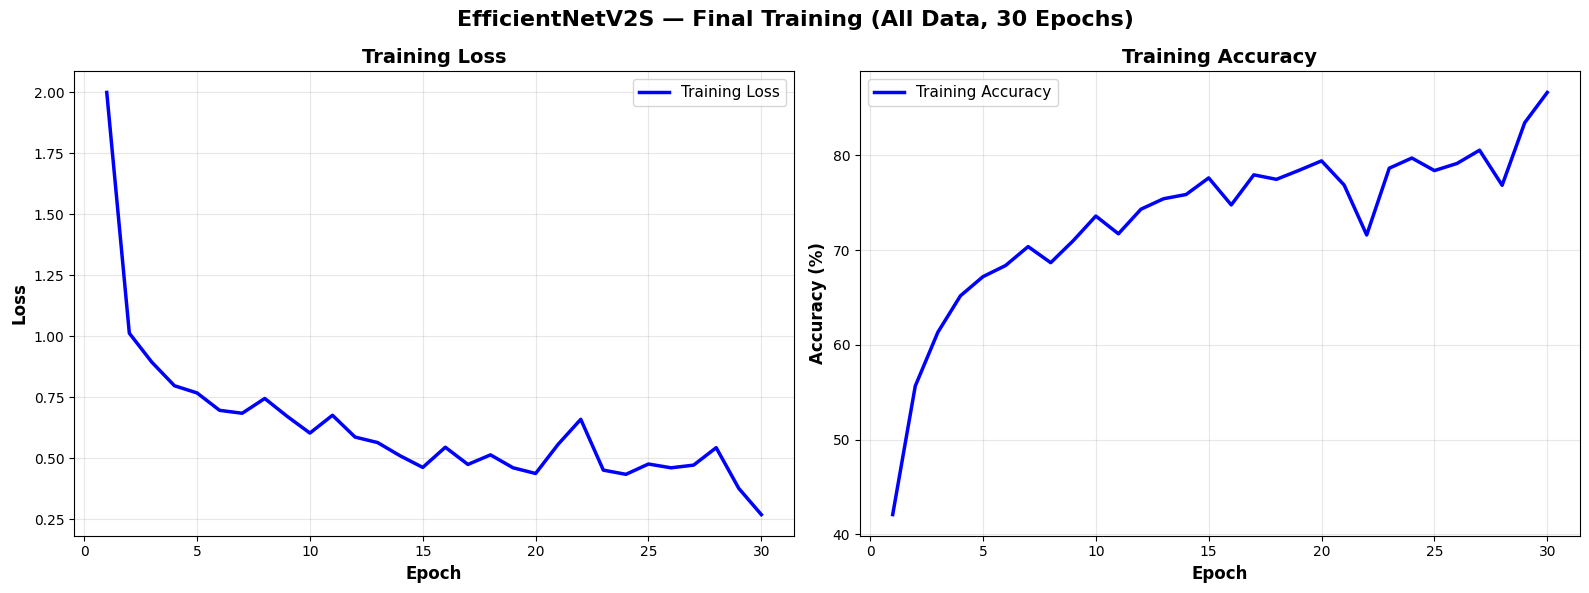

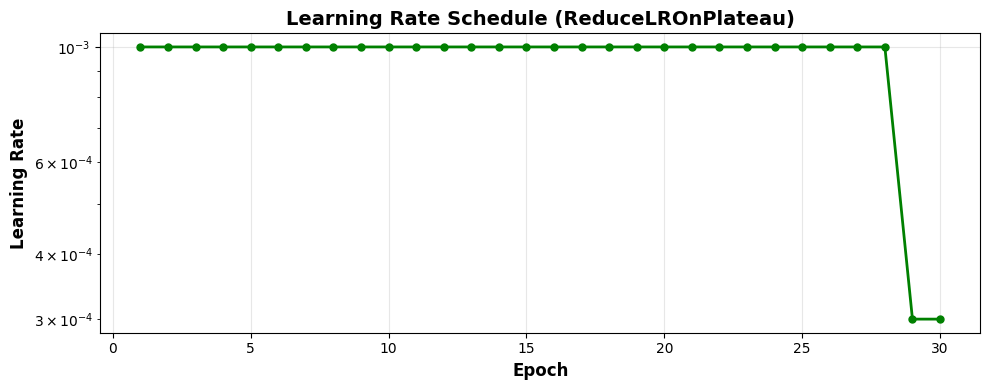

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{MODEL_NAME} — Final Training (All Data, {NUM_EPOCHS} Epochs)',
             fontsize=16, fontweight='bold')

epochs = range(1, len(history['train_loss']) + 1)

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', lw=2.5, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
train_acc_pct = [acc * 100 for acc in history['train_acc']]
ax.plot(epochs, train_acc_pct, 'b-', lw=2.5, label='Training Accuracy')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'efficientnetv2s_final_training_curves.png'),
            dpi=DPI, bbox_inches='tight')
plt.show()

# ── LR schedule visualization ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Reconstruct LR schedule from history
lr_values = []
temp_optimizer = torch.optim.Adam([torch.nn.Parameter(torch.zeros(1))], lr=LEARNING_RATE)
temp_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    temp_optimizer, mode='min', factor=0.3, patience=3, min_lr=1e-7
)
for e in range(len(history['train_loss'])):
    lr_values.append(temp_optimizer.param_groups[0]['lr'])
    temp_scheduler.step(history['train_loss'][e])

ax.plot(range(1, len(lr_values)+1), lr_values, 'g-o', lw=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test Set Evaluation

Evaluating the final model on the **reserved test set** — these images were **never seen** during cross-validation, head architecture search, or final training.

In [10]:
print(f"{'='*60}")
print(f"TEST SET EVALUATION")
print(f"{'='*60}")
print(f"Evaluating on {len(test_dataset)} test samples")
print(f"These samples were NEVER used during CV, head search, or training")
print(f"{'='*60}\n")

# ── Use TrainingEngine for evaluation ────────────────────────────────────────
test_loss, test_acc, test_predictions, test_true_labels, inference_time = engine.evaluate(
    test_loader, criterion, measure_inference_time=True
)

# ── Get probabilities for AUC calculation ────────────────────────────────────
model.eval()
all_probs = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

test_pred_proba = np.vstack(all_probs)

# ── Calculate comprehensive metrics (from utils) ────────────────────────────
test_metrics = calculate_metrics(
    y_true=test_true_labels,
    y_pred=test_predictions,
    y_pred_proba=test_pred_proba,
    class_names=classes,
    average='macro'
)

# ── Print comprehensive metrics ──────────────────────────────────────────────
print_metrics(test_metrics, title=f"{MODEL_NAME} — Test Set Results")

# ── Print classification report ──────────────────────────────────────────────
print_classification_report(test_true_labels, test_predictions, classes)

# ── Summary ──────────────────────────────────────────────────────────────────
correct = int(np.sum(test_predictions == test_true_labels))
incorrect = int(np.sum(test_predictions != test_true_labels))

print(f"\n{'='*60}")
print(f"TEST RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Total test samples  : {len(test_true_labels)}")
print(f"Correct predictions : {correct}")
print(f"Incorrect predictions: {incorrect}")
print(f"Test Accuracy       : {test_metrics['accuracy']*100:.2f}%")
print(f"Macro Precision     : {test_metrics['precision']*100:.2f}%")
print(f"Macro Recall        : {test_metrics['recall']*100:.2f}%")
print(f"Macro Specificity   : {test_metrics['specificity']*100:.2f}%")
print(f"Macro F1-Score      : {test_metrics['f1_score']*100:.2f}%")
print(f"MCC                 : {test_metrics['mcc']:.4f}")
if test_metrics.get('auc') is not None:
    print(f"Macro AUC-ROC       : {test_metrics['auc']:.4f}")
if inference_time is not None:
    print(f"\nInference Performance:")
    print(f"  Total time        : {inference_time['total_time']:.4f}s")
    print(f"  Avg per batch     : {inference_time['avg_time_per_batch']*1000:.2f}ms")
    print(f"  Avg per image     : {inference_time['avg_time_per_image']*1000:.2f}ms")
    print(f"  Images/second     : {inference_time['images_per_second']:.1f}")
print(f"{'='*60}")

TEST SET EVALUATION
Evaluating on 445 test samples
These samples were NEVER used during CV, head search, or training



Evaluating: 100%|██████████| 14/14 [00:01<00:00,  7.11it/s, loss=0.3537, acc=84.04%, time/batch=84.39ms]



                  EfficientNetV2S — Test Set Results                  

Overall Performance Metrics:
   Accuracy:    84.04%
   Precision:   81.64% (PPV - Positive Predictive Value)
   Recall:      86.53% (Sensitivity/TPR)
   Sensitivity: 86.53% (True Positive Rate)
   Specificity: 93.41% (True Negative Rate)
   F1-Score:    82.93% (F-Measure)
   MCC:         0.7434 (Matthews Correlation Coefficient)
   AUC-ROC:     0.9591 (Area Under Curve)

Metric Formulas:
   Precision (PPV) = TP / (TP + FP)
   Recall (Sensitivity) = TP / (TP + FN)
   Specificity = TN / (TN + FP)
   F1-Score = 2PR / (P + R)
   MCC = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))

Per-Class Detailed Metrics:

   Both:
      Precision (PPV):  92.11%
      Recall:           77.78%
      Sensitivity (TPR): 77.78%
      Specificity (TNR): 99.25%
      F1-Score:         84.34%

   Infection:
      Precision (PPV):  87.43%
      Recall:           79.27%
      Sensitivity (TPR): 79.27%
      Specificity (TNR): 91.27%
   

## 9. Test Set Visualizations

SUCCESS: Confusion matrix saved: results/efficientnetv2s_final/efficientnetv2s_final_confusion_matrix.png


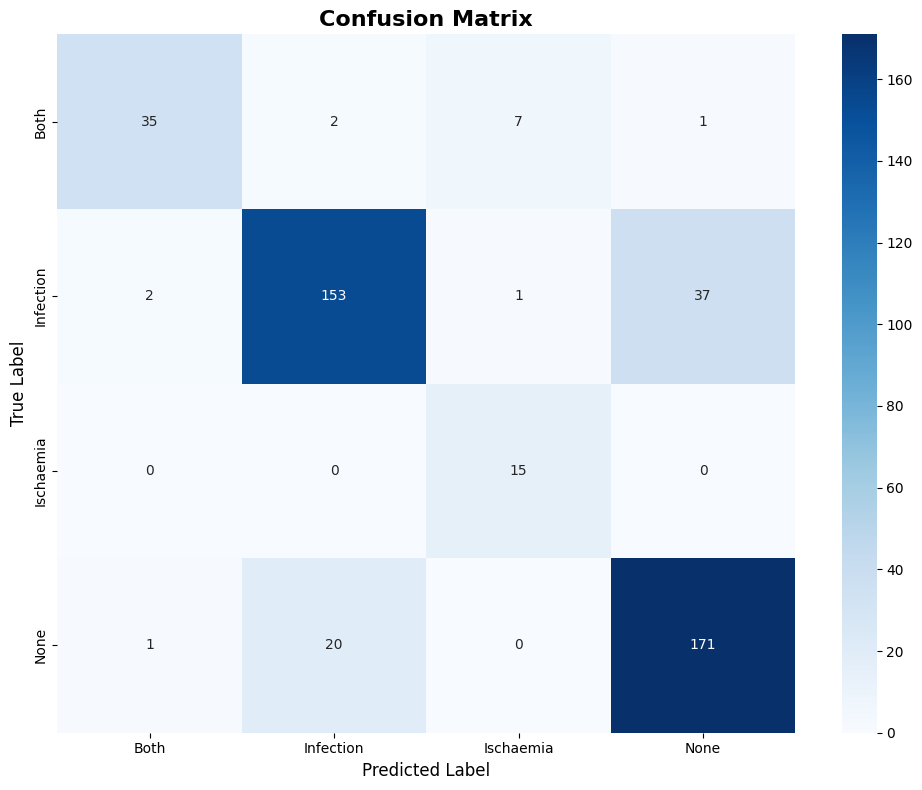

In [11]:
# 9.1 Confusion Matrix (Raw Counts)
plot_confusion_matrix(
    y_true=test_true_labels,
    y_pred=test_predictions,
    class_names=classes,
    figsize=(10, 8),
    normalize=False,
    save_path=os.path.join(RESULTS_DIR, 'efficientnetv2s_final_confusion_matrix.png')
)

SUCCESS: Confusion matrix saved: results/efficientnetv2s_final/efficientnetv2s_final_confusion_matrix_normalized.png


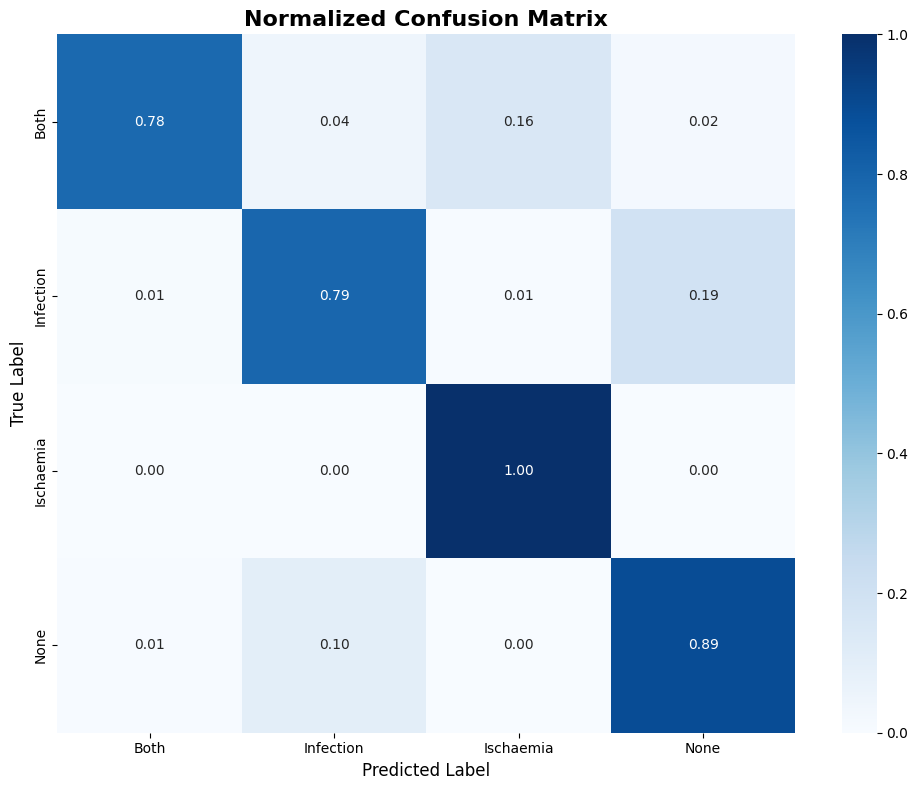

In [12]:
# 9.2 Confusion Matrix (Normalized)
plot_confusion_matrix(
    y_true=test_true_labels,
    y_pred=test_predictions,
    class_names=classes,
    figsize=(10, 8),
    normalize=True,
    save_path=os.path.join(RESULTS_DIR, 'efficientnetv2s_final_confusion_matrix_normalized.png')
)

SUCCESS: ROC curve saved: results/efficientnetv2s_final/efficientnetv2s_final_roc_curve.png


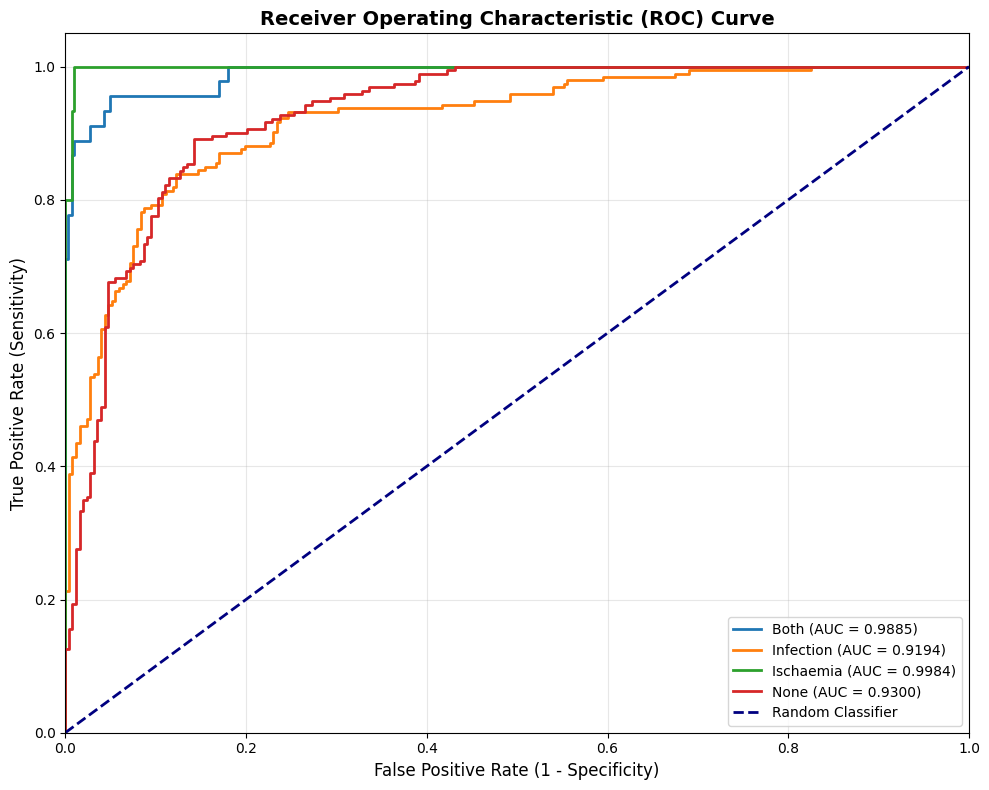

In [13]:
# 9.3 ROC Curve with Per-Class AUC
plot_roc_curve(
    y_true=test_true_labels,
    y_pred_proba=test_pred_proba,
    class_names=classes,
    save_path=os.path.join(RESULTS_DIR, 'efficientnetv2s_final_roc_curve.png')
)

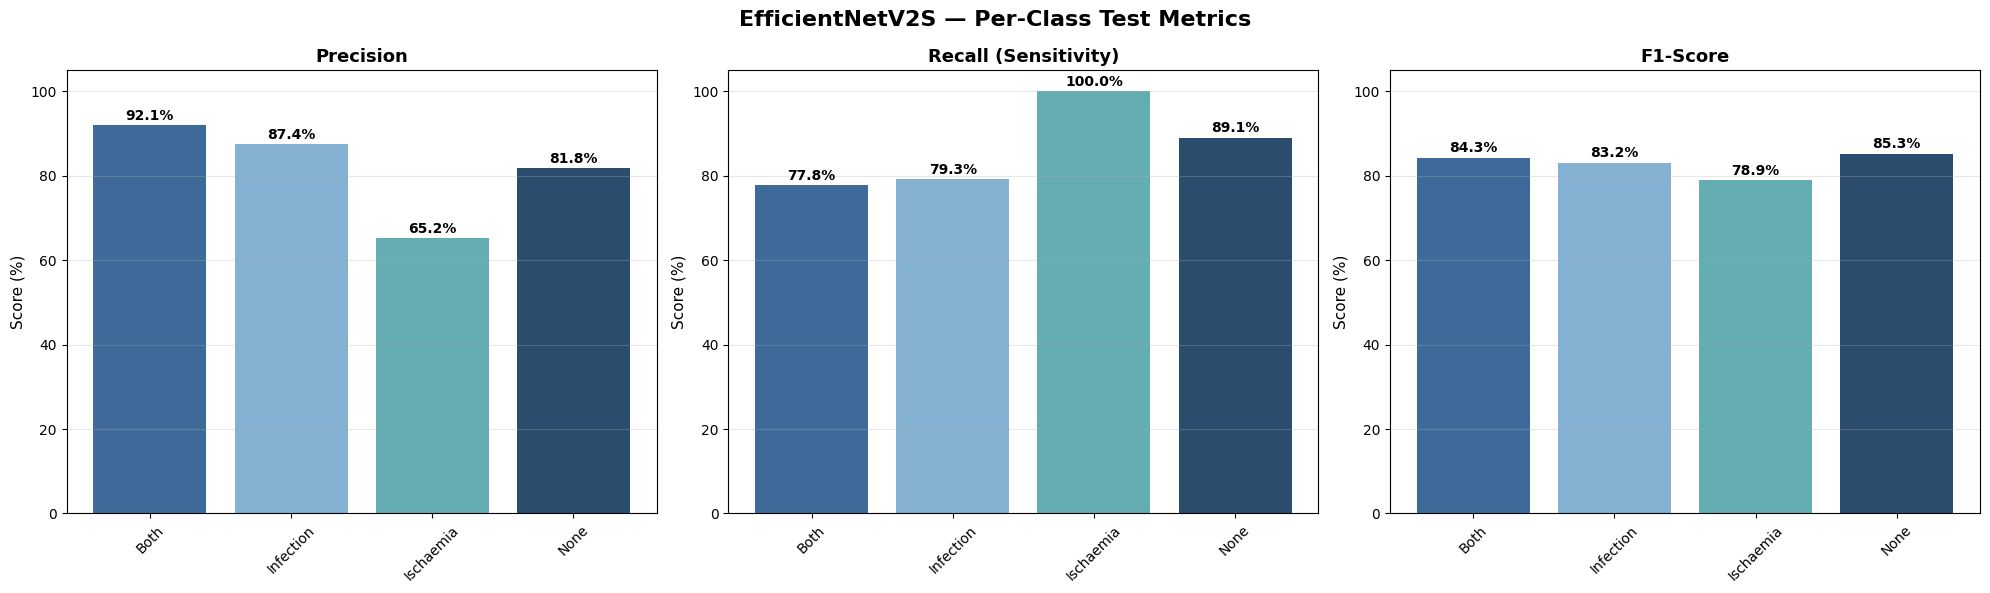

In [14]:
# 9.4 Per-Class Metrics Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'{MODEL_NAME} — Per-Class Test Metrics', fontsize=16, fontweight='bold')

metric_names = ['precision', 'recall', 'f1']
metric_titles = ['Precision', 'Recall (Sensitivity)', 'F1-Score']
colors = ['#3D6A99', '#85B1D2', '#64ADB3', '#2A4D6E']

for ax, metric_key, metric_title in zip(axes, metric_names, metric_titles):
    values = [test_metrics.get(f'{metric_key}_{cls}', 0) * 100 for cls in classes]
    bars = ax.bar(classes, values, color=colors)
    ax.set_title(metric_title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim([0, 105])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'efficientnetv2s_final_per_class_metrics.png'),
            dpi=DPI, bbox_inches='tight')
plt.show()

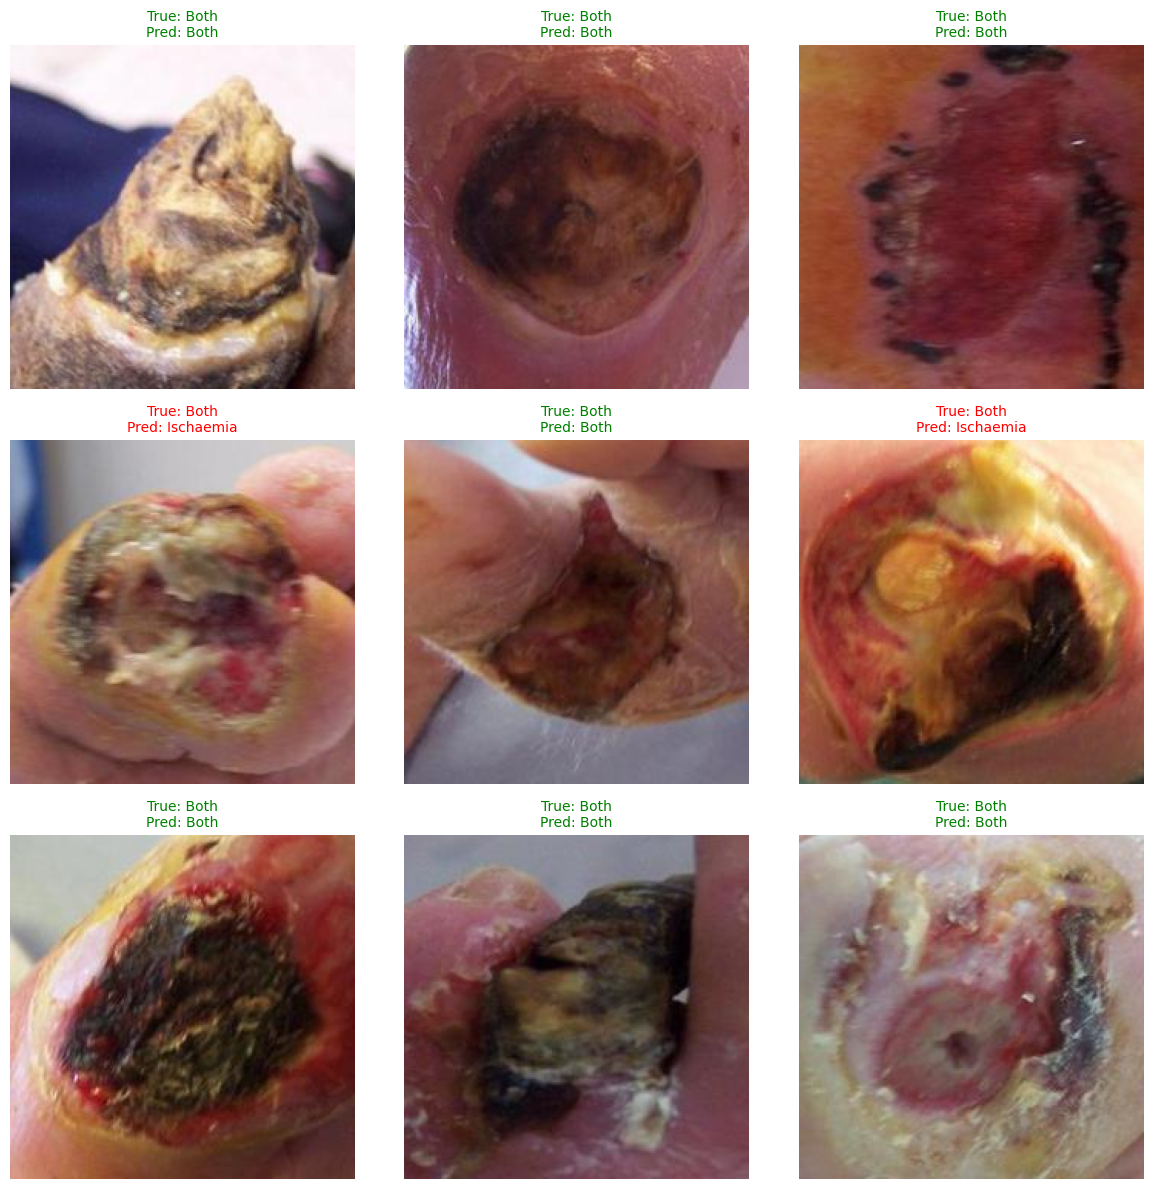

In [15]:
# 9.5 Sample Predictions
sample_images = []
sample_true = []
sample_pred = []
n_samples = 9

for i in range(min(n_samples, len(X_test))):
    img = Image.open(X_test[i]).convert('RGB')
    img = img.resize((224, 224))
    sample_images.append(np.array(img))
    sample_true.append(test_true_labels[i])
    sample_pred.append(test_predictions[i])

show_sample_predictions(
    images=sample_images,
    true_labels=sample_true,
    pred_labels=sample_pred,
    class_names=classes,
    rows=3,
    cols=3
)

## 10. Save Comprehensive Results

Comprehensive results JSON including model info, training config, head search reference, test metrics, per-class metrics, confusion matrix, and ROC curve data.

In [16]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

# ══════════════════════════════════════════════════════════════════════════════
# PER-CLASS DETAILED METRICS
# ══════════════════════════════════════════════════════════════════════════════
per_class_results = {}
cm = sk_confusion_matrix(test_true_labels, test_predictions)
y_true_bin = label_binarize(test_true_labels, classes=range(num_classes))

for i, class_name in enumerate(classes):
    class_mask = (test_true_labels == i)
    class_preds = (test_predictions == i)

    tp = int(np.sum((class_preds == True) & (class_mask == True)))
    fp = int(np.sum((class_preds == True) & (class_mask == False)))
    fn = int(np.sum((class_preds == False) & (class_mask == True)))
    tn = int(np.sum((class_preds == False) & (class_mask == False)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    try:
        auc_score = float(roc_auc_score(y_true_bin[:, i], test_pred_proba[:, i]))
    except:
        auc_score = 0.0

    # ROC curve data for this class
    fpr, tpr, thresh = roc_curve(y_true_bin[:, i], test_pred_proba[:, i])

    per_class_results[class_name] = {
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'specificity': float(specificity),
        'sensitivity': float(recall),
        'auc': auc_score,
        'support': int(np.sum(class_mask)),
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn,
        'true_negatives': tn,
        'roc_curve': {
            'fpr': fpr.tolist(),
            'tpr': tpr.tolist(),
            'thresholds': thresh.tolist(),
        }
    }

# ══════════════════════════════════════════════════════════════════════════════
# AGGREGATE AUC SCORES
# ══════════════════════════════════════════════════════════════════════════════
try:    macro_auc    = roc_auc_score(y_true_bin, test_pred_proba, average='macro',    multi_class='ovr')
except: macro_auc    = 0.0
try:    micro_auc    = roc_auc_score(y_true_bin, test_pred_proba, average='micro',    multi_class='ovr')
except: micro_auc    = 0.0
try:    weighted_auc = roc_auc_score(y_true_bin, test_pred_proba, average='weighted', multi_class='ovr')
except: weighted_auc = 0.0

try:    mcc_v   = float(matthews_corrcoef(test_true_labels, test_predictions))
except: mcc_v   = 0.0
try:    kappa_v = float(cohen_kappa_score(test_true_labels, test_predictions))
except: kappa_v = 0.0
try:    ll_v    = float(log_loss(test_true_labels, test_pred_proba))
except: ll_v    = 0.0

# ══════════════════════════════════════════════════════════════════════════════
# MODEL-LEVEL ROC BLOCK (for cross-model comparison)
# ══════════════════════════════════════════════════════════════════════════════
# Micro-average ROC
fpr_mi, tpr_mi, _ = roc_curve(y_true_bin.ravel(), test_pred_proba.ravel())

# Macro-average ROC (interpolated)
all_fpr = np.unique(np.concatenate([
    np.array(per_class_results[c]['roc_curve']['fpr']) for c in classes
]))
mean_tpr = np.zeros_like(all_fpr)
for c in classes:
    mean_tpr += np.interp(
        all_fpr,
        np.array(per_class_results[c]['roc_curve']['fpr']),
        np.array(per_class_results[c]['roc_curve']['tpr'])
    )
mean_tpr /= num_classes

model_level_roc = {
    'model_name':   MODEL_NAME,
    'architecture': 'EfficientNetV2-S + Custom Head (128 | gelu | drop=0.5)',
    'num_classes':  num_classes,
    'class_names':  classes,
    'test': {
        'macro_auc':    float(macro_auc),
        'micro_auc':    float(micro_auc),
        'weighted_auc': float(weighted_auc),
        'per_class_auc': {c: per_class_results[c]['auc'] for c in classes},
        'per_class': {
            c: {'fpr': per_class_results[c]['roc_curve']['fpr'],
                'tpr': per_class_results[c]['roc_curve']['tpr'],
                'auc': per_class_results[c]['auc']}
            for c in classes
        },
        'micro_average': {
            'fpr': fpr_mi.tolist(), 'tpr': tpr_mi.tolist(), 'auc': float(micro_auc)
        },
        'macro_average': {
            'fpr': all_fpr.tolist(), 'tpr': mean_tpr.tolist(), 'auc': float(macro_auc)
        },
    }
}

# ══════════════════════════════════════════════════════════════════════════════
# COMPILE COMPREHENSIVE RESULTS
# ══════════════════════════════════════════════════════════════════════════════
final_results = {
    'model_info': {
        'model_name': MODEL_NAME,
        'architecture': 'EfficientNetV2-S + Custom Head',
        'pretrained': True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size': [3, 224, 224],
        'num_classes': num_classes,
        'class_names': classes,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'head_parameters': head_params,
        'head_config': WINNER_HEAD_CONFIG,
    },
    'training_config': {
        'optimizer': 'Adam',
        'learning_rate': LEARNING_RATE,
        'weight_decay': 1e-4,
        'scheduler': 'ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)',
        'batch_size': BATCH_SIZE,
        'epochs': NUM_EPOCHS,
        'early_stopping': 'Disabled (fixed epochs from CV)',
        'loss_function': 'CrossEntropyLoss (balanced class weights)',
        'training_type': 'Final Training on ALL non-test data',
        'augmentation': {
            'horizontal_flip': 0.5,
            'vertical_flip':   0.5,
            'rotation':        20,
            'zoom_range':      [0.8, 1.2],
            'brightness':      0.1,
            'contrast':        0.1,
        }
    },
    'head_search_reference': {
        'note': 'Head architecture determined by head search experiment',
        'winner_trial': 4,
        'winner_config': '128 | drop=0.5 | gelu | noBN',
        'winner_5fold_mean_acc': 0.8343,
        'winner_5fold_std_acc':  0.0290,
        'winner_5fold_mean_f1':  0.8431,
        'winner_5fold_std_f1':   0.0182,
        'total_configs_tested':  21,
        'configs_in_phase2':     3,
    },
    'cv_reference': {
        'note': 'Cross-validation results from model selection phase',
        'cv_mean_accuracy': 0.8081,
        'cv_std_accuracy':  0.0172,
        'cv_folds': 5,
        'cv_avg_epochs': 29.2,
        'model_rank': '1st out of 6 models',
    },
    'dataset_info': {
        'total_samples': len(X_all) + len(X_test),
        'training_samples': len(X_all),
        'training_composition': f'train ({len(X_train)}) + valid ({len(X_val)})',
        'test_samples': len(X_test),
        'class_distribution_train': {
            classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)
        },
        'class_distribution_test': {
            classes[i]: int(np.sum(y_test == i)) for i in range(num_classes)
        },
    },
    'training_results': {
        'epochs_completed': NUM_EPOCHS,
        'final_train_accuracy': float(history['train_acc'][-1]),
        'final_train_loss': float(history['train_loss'][-1]),
        'training_time_minutes': round(training_time / 60, 2),
    },
    'test_results': {
        'total_samples': len(test_true_labels),
        'correct_predictions': correct,
        'incorrect_predictions': incorrect,
        'accuracy': float(test_metrics['accuracy']),
        'macro_precision': float(test_metrics['precision']),
        'macro_recall': float(test_metrics['recall']),
        'macro_sensitivity': float(test_metrics['sensitivity']),
        'macro_specificity': float(test_metrics['specificity']),
        'macro_f1_score': float(test_metrics['f1_score']),
        'mcc': mcc_v,
        'cohen_kappa': kappa_v,
        'log_loss': ll_v,
        'macro_auc_roc': float(macro_auc),
        'micro_auc_roc': float(micro_auc),
        'weighted_auc_roc': float(weighted_auc),
        'per_class_metrics': {
            c: {k: v for k, v in m.items() if k != 'roc_curve'}
            for c, m in per_class_results.items()
        },
        'confusion_matrix': {
            'matrix': cm.tolist(),
            'normalized': (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels': classes,
        },
        'inference_time': inference_time,
    },
    'model_level_roc': model_level_roc,
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'framework': 'PyTorch',
        'pytorch_version': torch.__version__,
        'cuda_available': torch.cuda.is_available(),
        'device': str(device),
        'seed': SEED,
        'experiment_name': 'efficientnetv2s_final_training',
    }
}

# ── Save results JSON ────────────────────────────────────────────────────────
results_json_path = os.path.join(RESULTS_DIR, 'efficientnetv2s_final_results.json')
with open(results_json_path, 'w') as f:
    json.dump(final_results, f, indent=2)
print(f"✓ Results saved: {results_json_path}")
file_size = os.path.getsize(results_json_path) / 1024
print(f"  File size: {file_size:.2f} KB")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print(f"{'FINAL RESULTS SUMMARY':^70}")
print(f"{'='*70}")
print(f"")
print(f"  Model: {MODEL_NAME} (EfficientNetV2-S + Custom Head)")
print(f"  Head:  128 | drop=0.5 | gelu | noBN (winner from head search)")
print(f"  Training: {len(X_all):,} samples, {NUM_EPOCHS} epochs (fixed)")
print(f"  Training Time: {training_time/60:.2f} minutes")
print(f"")
print(f"  --- Cross-Validation Reference ---")
print(f"  CV Accuracy: 80.81% ± 1.72% (5-fold, model selection phase)")
print(f"  Head Search Winner: 83.43% ± 2.90% (5-fold, head search phase)")
print(f"")
print(f"  --- Test Set Performance ({len(test_true_labels)} samples) ---")
print(f"  Accuracy     : {test_metrics['accuracy']*100:.2f}%")
print(f"  Precision    : {test_metrics['precision']*100:.2f}%")
print(f"  Recall       : {test_metrics['recall']*100:.2f}%")
print(f"  Specificity  : {test_metrics['specificity']*100:.2f}%")
print(f"  F1-Score     : {test_metrics['f1_score']*100:.2f}%")
print(f"  MCC          : {mcc_v:.4f}")
print(f"  Cohen Kappa  : {kappa_v:.4f}")
print(f"  Macro AUC    : {macro_auc:.4f}")
print(f"  Micro AUC    : {micro_auc:.4f}")
print(f"  Weighted AUC : {weighted_auc:.4f}")
print(f"  Log Loss     : {ll_v:.4f}")
print(f"")
print(f"  --- Per-Class Performance ---")
for cls_name, cls_m in per_class_results.items():
    print(f"  {cls_name}: P={cls_m['precision']:.4f} R={cls_m['recall']:.4f} "
          f"F1={cls_m['f1_score']:.4f} Spec={cls_m['specificity']:.4f} AUC={cls_m['auc']:.4f}")
print(f"")
print(f"  --- Saved Files ---")
print(f"  Model:   {final_model_path}")
print(f"  Results: {results_json_path}")
print(f"{'='*70}")

✓ Results saved: results/efficientnetv2s_final/efficientnetv2s_final_results.json
  File size: 40.56 KB

                        FINAL RESULTS SUMMARY                         

  Model: EfficientNetV2S (EfficientNetV2-S + Custom Head)
  Head:  128 | drop=0.5 | gelu | noBN (winner from head search)
  Training: 4,001 samples, 30 epochs (fixed)
  Training Time: 23.17 minutes

  --- Cross-Validation Reference ---
  CV Accuracy: 80.81% ± 1.72% (5-fold, model selection phase)
  Head Search Winner: 83.43% ± 2.90% (5-fold, head search phase)

  --- Test Set Performance (445 samples) ---
  Accuracy     : 84.04%
  Precision    : 81.64%
  Recall       : 86.53%
  Specificity  : 93.41%
  F1-Score     : 82.93%
  MCC          : 0.7434
  Cohen Kappa  : 0.7412
  Macro AUC    : 0.9591
  Micro AUC    : 0.9662
  Weighted AUC : 0.9336
  Log Loss     : 0.4280

  --- Per-Class Performance ---
  Both: P=0.9211 R=0.7778 F1=0.8434 Spec=0.9925 AUC=0.9885
  Infection: P=0.8743 R=0.7927 F1=0.8315 Spec=0.9127 AUC=0

## 11. Download Results (Kaggle)

In [17]:
# ── Zip results for download ──────────────────────────────────────────────────
import shutil

src_path = os.path.join(os.getcwd(), RESULTS_DIR)
zip_output = f'/kaggle/working/{MODEL_NAME.lower()}_final_results'

shutil.make_archive(zip_output, 'zip', src_path)
print(f"✓ Zipped → {zip_output}.zip")
print(f"  Size: {os.path.getsize(zip_output + '.zip') / (1024*1024):.2f} MB")

from IPython.display import FileLink
FileLink(f'{zip_output}.zip')

✓ Zipped → /kaggle/working/efficientnetv2s_final_results.zip
  Size: 73.54 MB


/kaggle/working/efficientnetv2s_final_results.zip